# Phase 6 — Notebook 25: the CSE-CIC-IDS2018 drift-localization benchmark (G-BENCH, P3–P6)

**Notebook:** `notebooks/08_phase6_cse2018/25_cse2018_benchmark.ipynb`
**Pre-registration:** PREREG_cse2018.md §4–5 + Addendum A1.4 + **Addendum A2** (commit A2 before running).
**Faithful clone of notebook 13** (which itself holds the 10b construction fixed): additive leave-one-family-out drift, per-feature **Wasserstein-1 anchor** (model-free drift truth), **domain-oracle-SHAP** circularity reference, localizers {KS, domain-SHAP, dual-IDS, perm-domain, random}, models {RF, XGB, MLP}, seeds {42, 1, 7}, precision@10, margin 0.05, self-stability. SHAP via `shap_importance_any` (TreeSHAP for trees, validated agnostic path for the MLP, F016).

**Adaptations from 13 → 25 (all pre-registered in A2, nothing else changes):**
1. Dataset: CSE-CIC-IDS2018 (improved), all ten processed days, families via the frozen `24_family_map.csv` taxonomy.
2. **Arms:** {DoS, DDoS, Infiltration, Bot}. **Web excluded** — underpowered (75 flows corpus-wide, census `24_family_power.csv`); injecting it produces no measurable marginal shift, making every GT meaningless. BruteForce is the known-at-training family and (as in 13) remains part of the baseline mixture, never an arm.
3. **Working pool:** 200k rows/day, stratified by attack_category, seed 42 (~2M rows). The construction draws only 4k-row windows, and z-scoring 15M×82 would exhaust Colab RAM; the pool is 10–100× larger than any draw, so the construction is unaffected.

**Pre-registered gate (A2), mirroring D027/D030 on the Wasserstein anchor (margin 0.05):**
- **C2-REPLICATES-2018** iff `dual − domain-SHAP ≤ margin` for ALL three models (P3) AND `KS − domain-SHAP ≥ −margin` for RF and XGB (P4).
- MLP `KS − domain-SHAP` is **P6, recorded either way** — on UNSW the MLP beat KS; on CICIDS it did not (drift-dependent boundary, §IV-G). 2018 is the tiebreaker regime point. If the MLP beats KS here, run the explainer control (clone of 13b) before interpreting.
- Circularity (P5): domain-SHAP inflation vs its own oracle, per model.

**Runtime:** ~45–75 min on hi-RAM Colab (4 arms × 3 models × 3 seeds; MLP SHAP dominates). Smoke check first: `SEEDS=[42]`, `ARMS=['DoS']`.

## 1. Setup (identical helpers to notebook 13)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import sys
sys.path.insert(0, '/content/drive/MyDrive/phd_thesis')
%pip install -q shap xgboost

import time, json, datetime
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from scipy.stats import spearmanr, wasserstein_distance

from src.utils.seeding import set_global_seed
from src.utils.documentation import log_finding, add_journal_entry
from src.data.loaders import load_dataset, CSE2018_DAY_ORDER
from src.divergence.localization import (
    shap_importance, ks_drift_scores, topk_indices, precision_at_k,
    jaccard, random_precision_expectation, shap_importance_any,
)

ROOT = Path('/content/drive/MyDrive/phd_thesis')
FIGURES = ROOT / 'reports' / 'figures'
TABLES = ROOT / 'reports' / 'tables'
DECISIONS_LOG = ROOT / 'reports' / 'advisor_notes' / 'decisions_log.md'
SUMMARY_JSON = ROOT / 'data' / 'processed' / 'phase6_25_cse2018_benchmark.json'

with open(ROOT / 'data' / 'processed' / 'phase1_06_metadata.json') as f:
    RF_PARAMS = json.load(f)['rf_hyperparameters']

PAPER_RCPARAMS = {
    'figure.dpi': 110, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05, 'savefig.facecolor': 'white',
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'font.family': 'serif', 'font.serif': ['DejaVu Serif', 'Times New Roman'],
    'font.size': 11, 'axes.titlesize': 12, 'axes.labelsize': 11,
    'xtick.labelsize': 10, 'ytick.labelsize': 10, 'legend.fontsize': 9,
    'axes.linewidth': 0.8, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linewidth': 0.5,
    'lines.linewidth': 1.8, 'lines.markersize': 6, 'pdf.fonttype': 42, 'ps.fonttype': 42,
}
mpl.rcParams.update(PAPER_RCPARAMS)
MODEL_COLOR = {'rf': '#E69F00', 'xgb': '#009E73', 'mlp': '#56B4E9'}

def save_figure(fig, name):
    fig.savefig(FIGURES / f'{name}.png'); fig.savefig(FIGURES / f'{name}.pdf')
    print(f'  saved: {name}.png / .pdf')

def log_decision(decision_id, decision, rationale, alternatives='',
                 context='25_cse2018_benchmark'):
    today = datetime.date.today().isoformat()
    if DECISIONS_LOG.exists() and f'## {decision_id} \u2014' in DECISIONS_LOG.read_text():
        print(f'[DECISION SKIPPED] {decision_id} already logged.'); return
    entry = (f'\n## {decision_id} \u2014 {today} \u2014 {context}\n\n'
             f'**Decision.** {decision}\n\n**Rationale.** {rationale}\n')
    if alternatives:
        entry += f'\n**Alternatives considered.** {alternatives}\n'
    with open(DECISIONS_LOG, 'a') as fh:
        fh.write(entry)
    print(f'[DECISION LOGGED] {decision_id}')

## 2. Pre-registered decision record (check decisions_log.md for the next free ID first)

In [3]:
log_decision(
    decision_id='D031',   # <-- bump if D031 is already taken in decisions_log.md
    decision=(
        'Replicate the drift-localization benchmark (D027/10b construction, D030/13 '
        'cross-model form) on CSE-CIC-IDS2018 (improved). Additive leave-one-family-out '
        'drift; arms {DoS, DDoS, Infiltration, Bot} per Addendum A2 (Web excluded, '
        'underpowered: 75 flows corpus-wide; BruteForce is the known-at-training family '
        'and stays in the baseline mixture). Working pool 200k rows/day stratified, '
        'seed 42. Localizers {KS, domain-SHAP, dual-IDS, perm-domain, random}; models '
        '{RF, XGB, MLP}; seeds {42,1,7}; GTs {wasserstein, domain_oracle_shap}; '
        'precision@10; margin 0.05; self-stability. Gate: C2-REPLICATES-2018 iff '
        'dual-dom <= margin for all models AND KS-dom >= -margin for RF and XGB; '
        'MLP KS-dom recorded either way (P6 open question from the paper section IV-G).'
    ),
    rationale=(
        'Third-dataset test of C1/C2 with all windows and gates fixed in advance '
        '(PREREG_cse2018 sections 4-5, A1.4, A2). 2018 is the regime tiebreaker for the '
        'drift-dependent MLP boundary: UNSW (weak marginal shift) had the MLP beat KS; '
        'CICIDS (strong shift) did not. G-DRIFT passed 5/5 decisive days (notebook 24), '
        'and geometry (notebook 23 v2) confirmed the unreachable decorrelated regime.'
    ),
    alternatives=(
        'Include Web at its natural 75 flows (rejected: no measurable marginal shift; '
        'every GT becomes noise). Upsample Web flows to WINDOW*INJECT_P (rejected: '
        'duplicated rows manufacture a synthetic drift signature). Full 15M-row pool '
        '(rejected: OOM for zero benefit; windows are 4k rows).'
    ),
)

[DECISION SKIPPED] D031 already logged.


## 3. Configuration (identical to 13 apart from the A2 adaptations)

In [4]:
set_global_seed(42)

WINDOW = 4000
INJECT_P = 0.5
ANCHOR_N = 4000
ORACLE_N = 4000
SHAP_SAMPLE = 800
PERM_EVAL = 1200
PERM_REPEATS = 3
SEEDS = [42, 1, 7]
MODELS = ['rf', 'xgb', 'mlp']
K_PRIMARY = 10
METHODS = ['ks', 'domain_shap', 'dual_ids', 'perm_domain', 'random']
GTS = ['wasserstein', 'domain_oracle_shap']
MARGIN = 0.05
MIN_FAMILY = 3000                       # >= WINDOW*INJECT_P rows to inject
ARMS = ['DoS', 'DDoS', 'Infiltration', 'Bot']   # A2: Web excluded
POOL_PER_DAY = 200_000                  # A2: working pool

MLP_PARAMS = dict(hidden_layer_sizes=(256, 128, 64), activation='relu',
                  alpha=1e-4, max_iter=300, early_stopping=True,
                  n_iter_no_change=15, random_state=42)

print(f'Arms {ARMS} | models {MODELS} | seeds {SEEDS} | inject_p {INJECT_P}')
print(f'Gate (Wasserstein, margin {MARGIN}): C2-REPLICATES-2018 iff dual-dom <= '
      f'{MARGIN} for all models AND KS-dom >= -{MARGIN} for RF/XGB; MLP KS-dom = P6.')

Arms ['DoS', 'DDoS', 'Infiltration', 'Bot'] | models ['rf', 'xgb', 'mlp'] | seeds [42, 1, 7] | inject_p 0.5
Gate (Wasserstein, margin 0.05): C2-REPLICATES-2018 iff dual-dom <= 0.05 for all models AND KS-dom >= -0.05 for RF/XGB; MLP KS-dom = P6.


## 4. Build the working pool (A2) and family labels

Family taxonomy comes from the frozen `24_family_map.csv` — not re-derived here.

**v2 (A2.5 deviation, log before re-running):** the v1 proportional subsample left Infiltration at 2,734 pool rows (< MIN_FAMILY). The pool builder now keeps ALL rows of arm families and fills the remaining per-day quota with a stratified sample of the rest — no duplicates, base-window composition shift < 1%.

In [5]:
fam_map_df = pd.read_csv(TABLES / '24_family_map.csv')
CAT_TO_FAM = dict(zip(fam_map_df['attack_category'], fam_map_df['family']))

# v2 pool builder (A2.5 deviation logged): rows belonging to ARM families are
# ALL kept (they are rare and are what the arms inject); the remaining per-day
# quota is filled with a stratified sample of everything else. No duplicates.
pool_X, pool_y, pool_fam = [], [], []
for day in CSE2018_DAY_ORDER:
    X_d, y_d, meta_d = load_dataset('cse_cic_ids2018', day=day)
    cats = meta_d['attack_category'].astype(str)
    fam_d = np.where(y_d.values == 1,
                     cats.map(CAT_TO_FAM).fillna('UNMAPPED').values, 'BENIGN')
    arm_idx = np.flatnonzero(np.isin(fam_d, ARMS))          # keep all arm rows
    rest_idx = np.setdiff1d(np.arange(len(y_d)), arm_idx)
    n_fill = max(0, POOL_PER_DAY - len(arm_idx))
    if len(rest_idx) > n_fill:
        frac = n_fill / len(rest_idx)
        fill = (pd.Series(rest_idx)
                  .groupby(cats.iloc[rest_idx].values, group_keys=False)
                  .apply(lambda g: g.sample(max(1, int(round(len(g)*frac))),
                                            random_state=42)).values)
    else:
        fill = rest_idx
    keep = np.concatenate([arm_idx, fill])
    pool_X.append(X_d.iloc[keep].to_numpy(dtype=np.float32))
    pool_y.append(y_d.iloc[keep].to_numpy())
    pool_fam.append(fam_d[keep])
    del X_d, y_d, meta_d
    print(f'pooled {day}  (arm rows kept: {len(arm_idx):,}, fill: {len(fill):,})')

FEATURE_COLS = list(load_dataset('cse_cic_ids2018', day='wed_14_02')[0].columns)
Xall = np.vstack(pool_X); y = np.concatenate(pool_y); fam = np.concatenate(pool_fam)
del pool_X, pool_y, pool_fam
assert not (fam == 'UNMAPPED').any(), 'attack category missing from 24_family_map.csv'

N_FEATURES = Xall.shape[1]
mu, sd = Xall.mean(0), Xall.std(0); sd[sd == 0] = 1.0
Xz = ((Xall - mu) / sd).astype(np.float32); del Xall
CHANCE = random_precision_expectation(K_PRIMARY, N_FEATURES)
benign_mask = (y == 0)

print(f'pool: {Xz.shape} | benign {int(benign_mask.sum()):,} | attack '
      f'{int((~benign_mask).sum()):,} | chance p@{K_PRIMARY} = {CHANCE:.3f}')
fam_counts = pd.Series(fam[~benign_mask]).value_counts()
print(fam_counts.to_string())
for H in ARMS:
    assert fam_counts.get(H, 0) >= MIN_FAMILY, f'{H} has < {MIN_FAMILY} pool rows'


pooled wed_14_02  (arm rows kept: 0, fill: 200,000)
pooled thu_15_02  (arm rows kept: 10,433, fill: 189,567)
pooled fri_16_02  (arm rows kept: 366,005, fill: 2)
pooled tue_20_02  (arm rows kept: 71,896, fill: 128,104)
pooled wed_21_02  (arm rows kept: 233,576, fill: 1)
pooled thu_22_02  (arm rows kept: 0, fill: 200,000)
pooled fri_23_02  (arm rows kept: 0, fill: 200,000)
pooled wed_28_02  (arm rows kept: 11,382, fill: 188,618)
pooled thu_01_03  (arm rows kept: 9,124, fill: 190,876)
pooled fri_02_03  (arm rows kept: 34,030, fill: 165,970)
pool: (2199584, 82) | benign 1,453,372 | attack 746,212 | chance p@10 = 0.122
DoS             376438
DDoS            305472
Bot              34030
Infiltration     20506
BruteForce        9751
Web                 15


## 5. Run the benchmark (arms × models × seeds) — construction identical to 13

`take` / `additive_post` / `imp`, the Wasserstein anchor (rng 777), the
domain-oracle-SHAP reference, dual-IDS, the 70/30 domain-classifier split,
permutation importance, and self-stability are copied verbatim from 13.

In [6]:
def make_model(kind, seed):
    if kind == 'rf':
        return RandomForestClassifier(**{**RF_PARAMS, 'random_state': seed})
    if kind == 'mlp':
        return MLPClassifier(**{**MLP_PARAMS, 'random_state': seed})
    from xgboost import XGBClassifier
    return XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                         subsample=0.9, colsample_bytree=0.9, n_jobs=-1,
                         tree_method='hist', random_state=seed, eval_metric='logloss')

def norm(v):
    v = np.abs(np.asarray(v, float)); s = v.sum(); return v / s if s > 0 else v

def take(pool, n, rng):
    idx = rng.choice(pool, size=min(n, len(pool)), replace=False)
    return Xz[idx], (~benign_mask[idx]).astype(int)

def additive_post(base_pool, hold_pool, n, rng):
    n_h = int(round(n * INJECT_P)); n_b = n - n_h
    bX, by = take(base_pool, n_b, rng); hX, hy = take(hold_pool, n_h, rng)
    X = np.vstack([bX, hX]); yids = np.concatenate([by, hy])
    order = rng.permutation(len(X)); return X[order], yids[order]

def imp(model, X_eval, X_bg, seed=42):
    return norm(shap_importance_any(model, X_eval, X_bg=X_bg, seed=seed))

rows, stab = [], []
t0 = time.time()
for H in ARMS:
    base_pool = np.where(benign_mask | (fam != H))[0]
    hold_pool = np.where((~benign_mask) & (fam == H))[0]

    arng = np.random.default_rng(777)
    preA, _ = take(base_pool, ANCHOR_N, arng)
    postA, _ = additive_post(base_pool, hold_pool, ANCHOR_N, arng)
    wass = np.array([wasserstein_distance(preA[:, j], postA[:, j])
                     for j in range(N_FEATURES)])

    for model in MODELS:
        oPre, _ = take(base_pool, ORACLE_N, arng)
        oPost, _ = additive_post(base_pool, hold_pool, ORACLE_N, arng)
        oX = np.vstack([oPre, oPost])
        oy = np.r_[np.zeros(len(oPre), int), np.ones(len(oPost), int)]
        odom = make_model(model, 42).fit(oX, oy)
        oi = np.random.default_rng(42).choice(len(oX), size=min(SHAP_SAMPLE, len(oX)),
                                              replace=False)
        gt_scores = {
            'wasserstein': norm(wass),
            'domain_oracle_shap': imp(odom, oX[oi], oX, seed=42),
        }
        gt_sets = {g: set(int(i) for i in topk_indices(s, K_PRIMARY))
                   for g, s in gt_scores.items()}

        per_seed_topk = {m: [] for m in METHODS}
        for seed in SEEDS:
            rng = np.random.default_rng(seed)
            preX, pre_y = take(base_pool, WINDOW, rng)
            postX, post_y = additive_post(base_pool, hold_pool, WINDOW, rng)

            f_pre = make_model(model, seed).fit(preX, pre_y)
            f_post = make_model(model, seed).fit(postX, post_y)
            sh = postX[rng.choice(len(postX), size=min(SHAP_SAMPLE, len(postX)),
                                  replace=False)]
            dual_ids = np.abs(imp(f_post, sh, postX, seed=seed) -
                              imp(f_pre, sh, preX, seed=seed))

            domX = np.vstack([preX, postX])
            domy = np.r_[np.zeros(len(preX), int), np.ones(len(postX), int)]
            dtr, dev = train_test_split(np.arange(len(domy)), train_size=0.7,
                                        stratify=domy, random_state=seed)
            dom = make_model(model, seed).fit(domX[dtr], domy[dtr])
            di = rng.choice(dev, size=min(SHAP_SAMPLE, len(dev)), replace=False)
            domain_shap = imp(dom, domX[di], domX[dtr], seed=seed)
            pe = rng.choice(dev, size=min(PERM_EVAL, len(dev)), replace=False)
            perm_domain = norm(np.clip(permutation_importance(
                dom, domX[pe], domy[pe], n_repeats=PERM_REPEATS,
                random_state=seed).importances_mean, 0, None))

            scores = {
                'ks': ks_drift_scores(preX, postX),
                'domain_shap': domain_shap,
                'dual_ids': dual_ids,
                'perm_domain': perm_domain,
                'random': rng.random(N_FEATURES),
            }
            for m, sc in scores.items():
                per_seed_topk[m].append(set(int(i) for i in topk_indices(sc, K_PRIMARY)))
                for g in GTS:
                    rho = spearmanr(sc, gt_scores[g]).correlation
                    rows.append({'family': H, 'model': model, 'seed': seed,
                                 'method': m, 'gt': g,
                                 'precision': precision_at_k(sc, gt_sets[g], K_PRIMARY),
                                 'spearman': float(rho) if rho == rho else 0.0})
        for m in METHODS:
            tk = per_seed_topk[m]
            js = [jaccard(tk[i], tk[j]) for i in range(len(tk))
                  for j in range(i + 1, len(tk))]
            stab.append({'family': H, 'model': model, 'method': m,
                         'self_stability': float(np.mean(js)) if js else float('nan')})
        print(f'  {H} / {model} done  ({time.time()-t0:.0f}s)')

res = pd.DataFrame(rows); stab_df = pd.DataFrame(stab)
res.to_csv(TABLES / '25_cse2018_raw.csv', index=False)
stab_df.to_csv(TABLES / '25_cse2018_stability.csv', index=False)
print(f'\n{len(res)} rows; {len(stab_df)} stability records.')

/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)


  DoS / rf done  (36s)


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)


  DoS / xgb done  (40s)


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)


...

  Bot / rf done  (428s)


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)


  Bot / xgb done  (432s)


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)


  Bot / mlp done  (522s)

360 rows; 60 stability records.


## 6. Aggregate — method × GT by model (as in 13 §7)

In [7]:
def cell(method, gt, model=None, col='precision'):
    q = (res['method'] == method) & (res['gt'] == gt)
    if model is not None:
        q &= (res['model'] == model)
    s = res[q][col]
    return float(s.mean()), float(s.std())

print('precision@%d on the Wasserstein anchor, by model:' % K_PRIMARY)
print(f'  {"model":<5} {"KS":>7} {"domSHAP":>9} {"dual":>7} {"perm":>7} {"random":>7}   KS-dom   dual-dom')
model_summary = {}
for model in MODELS:
    ksm = cell('ks', 'wasserstein', model)[0]
    dom = cell('domain_shap', 'wasserstein', model)[0]
    dual = cell('dual_ids', 'wasserstein', model)[0]
    perm = cell('perm_domain', 'wasserstein', model)[0]
    rnd = cell('random', 'wasserstein', model)[0]
    model_summary[model] = {'ks': ksm, 'domain_shap': dom, 'dual_ids': dual,
                            'perm_domain': perm, 'random': rnd,
                            'ks_minus_dom': ksm - dom, 'dual_minus_dom': dual - dom}
    print(f'  {model:<5} {ksm:>7.3f} {dom:>9.3f} {dual:>7.3f} {perm:>7.3f} {rnd:>7.3f}   '
          f'{ksm-dom:>+6.3f}   {dual-dom:>+6.3f}')
print(f'\nchance ~ {CHANCE:.3f}')

print('\nmodality-circularity & self-stability, by model:')
for model in MODELS:
    infl = (cell('domain_shap', 'domain_oracle_shap', model)[0]
            - cell('domain_shap', 'wasserstein', model)[0])
    dstab = stab_df[(stab_df['method'] == 'domain_shap')
                    & (stab_df['model'] == model)]['self_stability'].mean()
    pstab = stab_df[(stab_df['method'] == 'perm_domain')
                    & (stab_df['model'] == model)]['self_stability'].mean()
    model_summary[model]['circularity'] = float(infl)
    model_summary[model]['domain_shap_stability'] = float(dstab)
    model_summary[model]['perm_domain_stability'] = float(pstab)
    print(f'  {model:<5} circularity {infl:>+6.3f} | domain-SHAP stab {dstab:.3f} | '
          f'perm stab {pstab:.3f}')

pd.DataFrame(model_summary).T.to_csv(TABLES / '25_cse2018_model_summary.csv')

precision@10 on the Wasserstein anchor, by model:
  model      KS   domSHAP    dual    perm  random   KS-dom   dual-dom
  rf      0.425     0.367   0.383   0.258   0.075   +0.058   +0.017
  xgb     0.425     0.225   0.175   0.258   0.075   +0.200   -0.050
  mlp     0.425     0.550   0.492   0.375   0.075   -0.125   -0.058

chance ~ 0.122

modality-circularity & self-stability, by model:
  rf    circularity +0.425 | domain-SHAP stab 0.597 | perm stab 0.175
  xgb   circularity +0.433 | domain-SHAP stab 0.433 | perm stab 0.268
  mlp   circularity +0.067 | domain-SHAP stab 0.493 | perm stab 0.306


## 7. Figure — the 2018 analog of Fig. 8/9

  saved: 25_cse2018_benchmark.png / .pdf


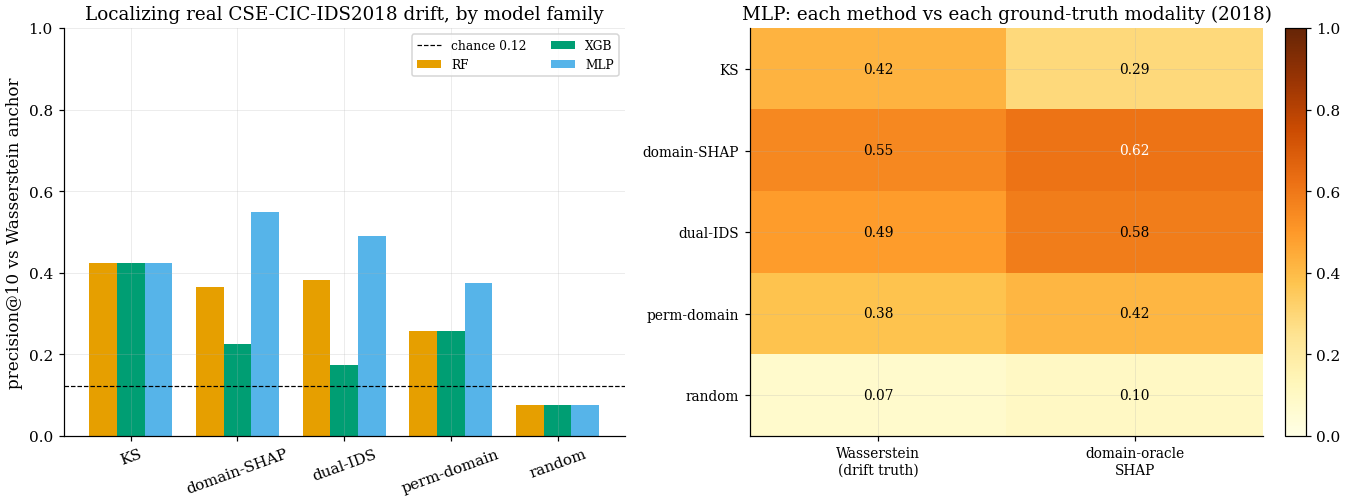

In [8]:
fig, (axA, axB) = plt.subplots(1, 2, figsize=(12.5, 4.8))
order = ['ks', 'domain_shap', 'dual_ids', 'perm_domain', 'random']
labels = ['KS', 'domain-SHAP', 'dual-IDS', 'perm-domain', 'random']
x = np.arange(len(order)); w = 0.26
for bi, model in enumerate(MODELS):
    vals = [cell(m, 'wasserstein', model)[0] for m in order]
    axA.bar(x + (bi - 1) * w, vals, width=w, color=MODEL_COLOR[model],
            label=model.upper())
axA.axhline(CHANCE, ls='--', color='black', lw=0.8, label=f'chance {CHANCE:.2f}')
axA.set_xticks(x); axA.set_xticklabels(labels, rotation=20)
axA.set_ylabel(f'precision@{K_PRIMARY} vs Wasserstein anchor')
axA.set_ylim(0, 1.0)
axA.set_title('Localizing real CSE-CIC-IDS2018 drift, by model family')
axA.legend(fontsize=8, ncol=2)

gt_labels = {'wasserstein': 'Wasserstein\n(drift truth)',
             'domain_oracle_shap': 'domain-oracle\nSHAP'}
M = np.array([[cell(m, g, 'mlp')[0] for g in GTS] for m in METHODS])
im = axB.imshow(M, cmap='YlOrBr', vmin=0, vmax=1, aspect='auto')
axB.set_xticks(range(len(GTS)))
axB.set_xticklabels([gt_labels[g] for g in GTS], fontsize=9)
axB.set_yticks(range(len(METHODS))); axB.set_yticklabels(labels, fontsize=9)
for i in range(len(METHODS)):
    for j in range(len(GTS)):
        axB.text(j, i, f'{M[i, j]:.2f}', ha='center', va='center', fontsize=9,
                 color='black' if M[i, j] < 0.6 else 'white')
axB.set_title('MLP: each method vs each ground-truth modality (2018)')
fig.colorbar(im, ax=axB, fraction=0.046, pad=0.04)
fig.tight_layout(); save_figure(fig, '25_cse2018_benchmark'); plt.show()

## 8. Pre-registered verdict (A2 gate: P3, P4, P5, P6)

In [9]:
p3_all = all(model_summary[m]['dual_minus_dom'] <= MARGIN for m in MODELS)
p4_trees = all(model_summary[m]['ks_minus_dom'] >= -MARGIN for m in ['rf', 'xgb'])
p6_mlp_ks_minus_dom = model_summary['mlp']['ks_minus_dom']
mlp_beats_ks = (-p6_mlp_ks_minus_dom) > MARGIN   # domain-SHAP_mlp - KS > margin

verdict = ('C2-REPLICATES-2018' if (p3_all and p4_trees) else
           'DUAL-HELPS-2018' if not p3_all else
           'KS-NOT-COMPETITIVE-TREES-2018')

print('=' * 76)
print(f'CSE-CIC-IDS2018 DRIFT-LOCALIZATION BENCHMARK VERDICT (A2)  -- precision@{K_PRIMARY}')
print('=' * 76)
print(f'  arms {ARMS} | models {MODELS} | seeds {SEEDS} | chance {CHANCE:.3f}')
for m in MODELS:
    s = model_summary[m]
    print(f'  {m}: KS {s["ks"]:.3f} | dom {s["domain_shap"]:.3f} | dual '
          f'{s["dual_ids"]:.3f} | KS-dom {s["ks_minus_dom"]:+.3f} | dual-dom '
          f'{s["dual_minus_dom"]:+.3f} | circ {s["circularity"]:+.3f}')
print(f'  P3 (dual adds nothing, all models): {p3_all}')
print(f'  P4 (KS competitive, trees): {p4_trees}')
print(f'  P5 (circularity inflation > +0.10): '
      f'{ {m: model_summary[m]["circularity"] > 0.10 for m in MODELS} }')
print(f'  P6 (MLP): KS-dom = {p6_mlp_ks_minus_dom:+.3f} '
      f'-> MLP {"BEATS" if mlp_beats_ks else "does NOT beat"} KS on 2018')
print('-' * 76)
print(f'--> VERDICT: {verdict}')
if mlp_beats_ks:
    print('    NOTE: MLP beat KS -> run the explainer control (clone of 13b) '
          'before interpreting; UNSW-like regime point.')
else:
    print('    NOTE: MLP did not beat KS -> CICIDS-like regime point; the '
          'drift-dependent boundary of section IV-G now has a 2-vs-1 split '
          'across three datasets.')

CSE-CIC-IDS2018 DRIFT-LOCALIZATION BENCHMARK VERDICT (A2)  -- precision@10
  arms ['DoS', 'DDoS', 'Infiltration', 'Bot'] | models ['rf', 'xgb', 'mlp'] | seeds [42, 1, 7] | chance 0.122
  rf: KS 0.425 | dom 0.367 | dual 0.383 | KS-dom +0.058 | dual-dom +0.017 | circ +0.425
  xgb: KS 0.425 | dom 0.225 | dual 0.175 | KS-dom +0.200 | dual-dom -0.050 | circ +0.433
  mlp: KS 0.425 | dom 0.550 | dual 0.492 | KS-dom -0.125 | dual-dom -0.058 | circ +0.067
  P3 (dual adds nothing, all models): True
  P4 (KS competitive, trees): True
  P5 (circularity inflation > +0.10): {'rf': True, 'xgb': True, 'mlp': False}
  P6 (MLP): KS-dom = -0.125 -> MLP BEATS KS on 2018
----------------------------------------------------------------------------
--> VERDICT: C2-REPLICATES-2018
    NOTE: MLP beat KS -> run the explainer control (clone of 13b) before interpreting; UNSW-like regime point.


## 9. Save summary + log finding

In [10]:
SUMMARY = {
    'generated': datetime.datetime.now().isoformat(timespec='seconds'),
    'dataset': 'CSE-CIC-IDS2018 (improved)',
    'drift': 'additive leave-one-family-out (inject H at P)',
    'inject_p': INJECT_P, 'n_features': N_FEATURES, 'arms': ARMS,
    'web_excluded_underpowered': True, 'pool_per_day': POOL_PER_DAY,
    'models': MODELS, 'seeds': SEEDS, 'k': K_PRIMARY, 'chance': CHANCE,
    'margin': MARGIN, 'gts': GTS, 'by_model': model_summary,
    'gate': {'P3_dual_adds_nothing_all_models': bool(p3_all),
             'P4_ks_competitive_trees': bool(p4_trees),
             'P6_mlp_ks_minus_dom': float(p6_mlp_ks_minus_dom),
             'P6_mlp_beats_ks': bool(mlp_beats_ks)},
    'verdict': verdict,
    'mirrors': 'notebook 13 / D030 construction; A2 adaptations only',
}
with open(SUMMARY_JSON, 'w') as f:
    json.dump(SUMMARY, f, indent=2, default=str)
print(f'Saved {SUMMARY_JSON}')

# Fill numbers, set the next free finding_id, then uncomment:
# log_finding(
#     finding_id='F0XX',
#     title='CSE-CIC-IDS2018 drift-localization benchmark: <verdict>',
#     context='08_phase6_cse2018/25_cse2018_benchmark',
#     what_we_did='Replicated the 10b/13 benchmark on the third dataset per '
#                 'PREREG A1.4/A2 (arms DoS/DDoS/Infiltration/Bot; Web excluded '
#                 'underpowered; identical construction, anchor, localizers).',
#     what_we_found='<per-model KS/dom/dual, P3-P6, circularity, stability>',
#     why_it_matters='Third-dataset evidence for C1/C2 and the tiebreaker for '
#                    'the drift-dependent MLP boundary (IV-G).',
# )

Saved /content/drive/MyDrive/phd_thesis/data/processed/phase6_25_cse2018_benchmark.json


## 10. Routing

- **C2-REPLICATES-2018 & MLP does not beat KS** → fold into
  `99_paper_figures/15_significance_tests` (36 new pairs), update paper Tables
  II–V + abstract to three datasets. Done with Phase 6 benchmarking.
- **MLP beats KS** → clone 13b as `25b_cse2018_explainer_control` first; the
  regime diagnostic (per-feature KS_max on injected families, as in the
  CICIDS/UNSW contrast) becomes a paper subsection either way.
- **DUAL-HELPS-2018** (would contradict two datasets) → treat as a probable
  bug first: re-check the pool build and the A2 arms before believing it.